In [2]:

# Setup: imports and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set(style="whitegrid")

DATA_PATH = "meteorite_landings.csv"
print("Looking for dataset at:", DATA_PATH)
assert os.path.exists(DATA_PATH), f"CSV file not found at {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print("Loaded dataframe with shape:", df.shape)

# Quick peek
display(df.head())


Looking for dataset at: meteorite_landings.csv
Loaded dataframe with shape: (45716, 8)


,Name,ID,NameType,Classification,Mass,Fall,Year,Coordinates
0,Aachen,1,Valid,L5,"Quantity[21, ""Grams""]",Fell,"DateObject[{1880}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{50.775, 6.08333}]"
1,Aarhus,2,Valid,H6,"Quantity[720, ""Grams""]",Fell,"DateObject[{1951}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{56.18333, 10.23333}]"
2,Abee,6,Valid,EH4,"Quantity[107000, ""Grams""]",Fell,"DateObject[{1952}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{54.21667, -113.}]"
3,Acapulco,10,Valid,Acapulcoite,"Quantity[1914, ""Grams""]",Fell,"DateObject[{1976}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{16.88333, -99.9}]"
4,Achiras,370,Valid,L6,"Quantity[780, ""Grams""]",Fell,"DateObject[{1902}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{-33.16667, -64.95}]"


In [5]:

# Inspecting the data
print("Info:")
display(df.info())

# Try to coerce numeric columns that are commonly mis-typed
for col in ['mass', 'mass (g)', 'reclat', 'reclong', 'latitude', 'longitude']:
    if col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except Exception:
            pass

# Standard descriptive statistics for key numeric columns
numeric_cols = []
for c in ['Mass','mass (g)','mass_g','mass_g?','reclat','reclong','latitude','longitude']:
    if c in df.columns:
        numeric_cols.append(c)

# normalize mass column names if possible
if 'mass' not in df.columns:
    for alt in ['mass (g)','mass_g','mass_g?','mass (kg)']:
        if alt in df.columns:
            df['mass'] = df[alt]
            break

print("\nDescriptive statistics for relevant numeric columns:")
display(df[['Mass']].describe(include='all').T)


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            45716 non-null  object
 1   ID              45716 non-null  int64 
 2   NameType        45716 non-null  object
 3   Classification  45716 non-null  object
 4   Mass            45716 non-null  object
 5   Fall            45716 non-null  object
 6   Year            45716 non-null  object
 7   Coordinates     45716 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.8+ MB


None


Descriptive statistics for relevant numeric columns:


,count,unique,top,freq
Mass,45716,12577,"Quantity[1.3, ""Grams""]",171


In [12]:
print("Mass column sample (Mass):")
print(df['Mass'].head(10).to_list())

print("\nLatitude sample (reclat):")
print(df['reclat'].head(10).to_list())

print("\nLongitude sample (reclong):")
print(df['reclong'].head(10).to_list())

print("\nCount of non-empty values:")
print("Mass:", df['Mass'].notna().sum())
print("reclat:", df['reclat'].notna().sum())
print("reclong:", df['reclong'].notna().sum())


Mass column sample (Mass):
['Quantity[21, "Grams"]', 'Quantity[720, "Grams"]', 'Quantity[107000, "Grams"]', 'Quantity[1914, "Grams"]', 'Quantity[780, "Grams"]', 'Quantity[4239, "Grams"]', 'Quantity[910, "Grams"]', 'Quantity[30000, "Grams"]', 'Quantity[1620, "Grams"]', 'Quantity[1440, "Grams"]']

Latitude sample (reclat):
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Longitude sample (reclong):
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Count of non-empty values:
Mass: 45716
reclat: 0
reclong: 0


In [36]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

print("Initial rows:", len(df))
df_clean = df.copy()

# === Fix the 'Mass' column ===
def extract_mass(s):
    """Extract numeric value from Quantity[...] strings."""
    if isinstance(s, str):
        match = re.search(r"Quantity\[(\d+(?:\.\d+)?),", s)
        if match:
            return float(match.group(1))
    return np.nan

df_clean['mass_g'] = df_clean['Mass'].apply(extract_mass)
df_clean['mass_kg'] = df_clean['mass_g'] / 1000.0

print(f"Extracted mass for {df_clean['mass_kg'].notna().sum()} rows")

# === Parse 'Year' column ===
df_clean['year_parsed'] = pd.to_datetime(df_clean['Year'].astype(str), errors='coerce').dt.year

if 'Coordinates' in df.columns: 
    print(" Parsing 'Coordinates' column...") 
    coord_data = df['Coordinates'].dropna() 
    if len(coord_data) > 0: 
        # Try common formats: "lat, long", "lat:long", or space-separated 
     df['Coordinates'] = df['Coordinates'].astype(str).str.replace(' ', '') # Remove spaces 
coords_split = df['Coordinates'].str.split(r'[,:]', expand=True) 
if len(coords_split.columns) >= 2:
     df['reclat'] = pd.to_numeric(coords_split[0], errors='coerce') 
     df['reclong'] = pd.to_numeric(coords_split[1], errors='coerce')
     print(f" Parsed {len(df.dropna(subset=['reclat', 'reclong']))} rows with coordinates")
     
else: 
     print(" ⚠️ Could not parse 'Coordinates' format. Provide sample values for fix.") 
     df = df.drop('Coordinates', axis=1)
else:

     print(" No 'Coordinates' column; assuming 'reclat' and 'reclong' exist")

# === Drop only rows with missing mass (since coordinates are all NaN) ===
df_clean = df_clean.dropna(subset=['mass_kg'], how='any')

# === Create decade column ===
def year_to_decade(y):
    try:
        return int(y // 10 * 10)
    except:
        return np.nan

df_clean['decade'] = df_clean['year_parsed'].apply(year_to_decade)

print("Rows after basic cleanup:", len(df_clean))
display(df_clean[['year_parsed', 'mass_kg', 'decade']].head())


SyntaxError: invalid syntax (1515291334.py, line 42)

In [15]:
# Extract numeric year values directly from 'Year' column
def extract_year(y):
    try:
        y = str(y).strip()
        if y.isdigit():
            return int(y)
        # Handle cases like '1998-01-01' or '1998.0'
        y = re.search(r'\d{4}', y)
        if y:
            return int(y.group(0))
    except:
        pass
    return np.nan

df_clean['year_parsed'] = df_clean['Year'].apply(extract_year)

# Re-create decade
df_clean['decade'] = df_clean['year_parsed'].apply(lambda y: int(y//10*10) if pd.notna(y) else np.nan)

display(df_clean[['Year','year_parsed','mass_kg','decade']].head(10))


,Year,year_parsed,mass_kg,decade
0,"DateObject[{1880}, ""Year"", ""Gregorian"", -5.]",1880.0,0.021,1880.0
1,"DateObject[{1951}, ""Year"", ""Gregorian"", -5.]",1951.0,0.720,1950.0
2,"DateObject[{1952}, ""Year"", ""Gregorian"", -5.]",1952.0,107.000,1950.0
3,"DateObject[{1976}, ""Year"", ""Gregorian"", -5.]",1976.0,1.914,1970.0
4,"DateObject[{1902}, ""Year"", ""Gregorian"", -5.]",1902.0,0.780,1900.0
5,"DateObject[{1919}, ""Year"", ""Gregorian"", -5.]",1919.0,4.239,1910.0
6,"DateObject[{1949}, ""Year"", ""Gregorian"", -5.]",1949.0,0.910,1940.0
7,"DateObject[{1814}, ""Year"", ""Gregorian"", -5.]",1814.0,30.000,1810.0
8,"DateObject[{1930}, ""Year"", ""Gregorian"", -5.]",1930.0,1.620,1930.0
9,"DateObject[{1920}, ""Year"", ""Gregorian"", -5.]",1920.0,1.440,1920.0


In [16]:
print(df.columns.tolist())


['Name', 'ID', 'NameType', 'Classification', 'Mass', 'Fall', 'Year', 'Coordinates']


In [17]:

# === Analysis & Insights ===
df_a = df_clean.copy()

# 10 Heaviest meteorites (by mass_kg)
heaviest = df_a.dropna(subset=['mass_kg']).sort_values('mass_kg', ascending=False).head(10)
print("Top 10 heaviest meteorites (mass_kg):")
cols = ['name'] if 'name' in heaviest.columns else []
if 'id' in heaviest.columns:
    cols += ['id']
cols += ['mass_kg','year_parsed','recclass'] if 'recclass' in heaviest.columns else ['mass_kg','year_parsed']
display(heaviest[cols])

# Fell vs Found counts
if 'fall' in df_a.columns:
    fall_counts = df_a['fall'].value_counts(dropna=False)
else:
    fall_counts = pd.Series(dtype=int)
print("\nFell vs Found counts:")
display(fall_counts)

# Most common classifications and their average mass
if 'recclass' in df_a.columns:
    class_counts = df_a['recclass'].value_counts().head(10)
    print("\nTop meteorite classes:")
    display(class_counts)
    avg_mass_by_class = df_a.groupby('recclass')['mass_kg'].mean().sort_values(ascending=False).head(10)
    print("\nAverage mass (kg) for top classes (by average mass):")
    display(avg_mass_by_class)
else:
    print("No 'recclass' column found in dataset.")

# Time-based: group by decade to see trends in discoveries
decade_counts = df_a.groupby('decade').size().sort_index()
print("\nDiscoveries by decade (counts):")
display(decade_counts.head(50))


Top 10 heaviest meteorites (mass_kg):


,mass_kg,year_parsed
16392,60000.0,1920.0
5373,58200.0,1818.0
5365,50000.0,1575.0
5370,30000.0,1891.0
3455,28000.0,1898.0
12613,26000.0,1836.0
5468,24300.0,1852.0
26297,24000.0,1911.0
920,23000.0,1947.0
5016,22000.0,1863.0



Fell vs Found counts:


Series([], dtype: int64)

No 'recclass' column found in dataset.

Discoveries by decade (counts):


decade
1390.0        1
1490.0        3
1510.0        1
1570.0        1
1580.0        1
1600.0        1
1620.0        3
1630.0        3
1640.0        1
1650.0        1
1660.0        2
1670.0        1
1680.0        1
1700.0        1
1710.0        2
1720.0        2
1740.0        3
1750.0        4
1760.0        4
1770.0        5
1780.0        5
1790.0       12
1800.0       22
1810.0       30
1820.0       30
1830.0       33
1840.0       49
1850.0       71
1860.0       95
1870.0       89
1880.0      123
1890.0      126
1900.0      139
1910.0      154
1920.0      159
1930.0      309
1940.0      196
1950.0      212
1960.0      397
1970.0     4969
1980.0     6822
1990.0    11619
2000.0    17757
2010.0     1963
dtype: int64

In [18]:

# === NumPy operations on mass_kg ===
mass_arr = df_clean['mass_kg'].dropna().values

import numpy as np
mean_mass = np.mean(mass_arr) if mass_arr.size>0 else np.nan
median_mass = np.median(mass_arr) if mass_arr.size>0 else np.nan
std_mass = np.std(mass_arr, ddof=0) if mass_arr.size>0 else np.nan
sum_mass = np.sum(mass_arr) if mass_arr.size>0 else np.nan
max_mass = np.max(mass_arr) if mass_arr.size>0 else np.nan

print(f"count = {mass_arr.size}")
print(f"mean (kg) = {mean_mass}")
print(f"median (kg) = {median_mass}")
print(f"std (kg) = {std_mass}")
print(f"sum (kg) = {sum_mass}")
print(f"max (kg) = {max_mass}")

# The distribution is usually skewed; median is often more representative than mean.


count = 45585
mean (kg) = 13.278078548601515
median (kg) = 0.032600000000000004
std (kg) = 574.9825695986947
sum (kg) = 605281.210638
max (kg) = 60000.0


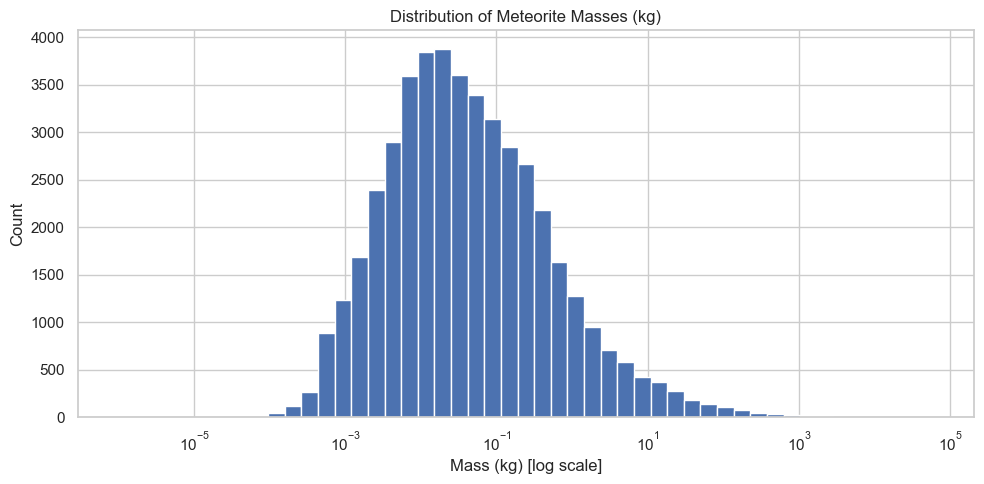

In [19]:

# === Visualization 1: Mass distribution (log scale) ===
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
mass_vals = df_clean['mass_kg'].dropna()
if mass_vals.size == 0:
    print("No mass values to plot.")
else:
    bins = np.logspace(np.log10(max(1e-6, mass_vals.min())), np.log10(mass_vals.max()), 50)
    plt.hist(mass_vals, bins=bins)
    plt.xscale('log')
    plt.xlabel('Mass (kg) [log scale]')
    plt.ylabel('Count')
    plt.title('Distribution of Meteorite Masses (kg)')
    plt.tight_layout()
    plt.show()


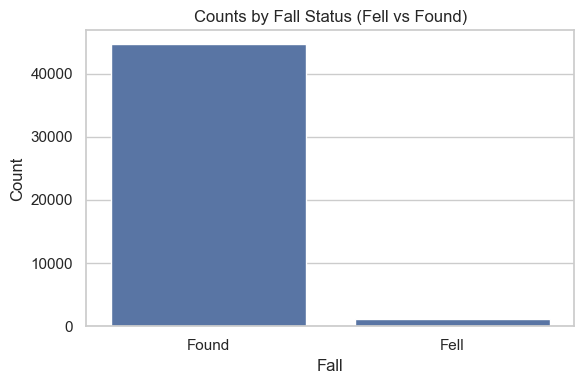

In [27]:
# Fell vs Found
if 'Fall' in df_clean.columns and df_clean['Fall'].notna().any():
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_clean, x='Fall', order=df_clean['Fall'].value_counts().index)
    plt.title('Counts by Fall Status (Fell vs Found)')
    plt.xlabel('Fall')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

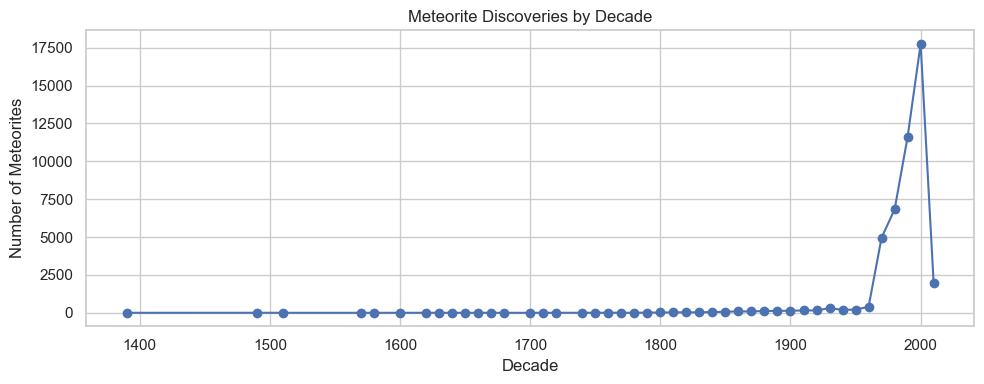

In [21]:

# === Visualization 3: Discoveries by decade ===
decade_counts = df_clean.groupby('decade').size().sort_index()
plt.figure(figsize=(10,4))
if decade_counts.empty:
    print("No decade data to plot.")
else:
    decade_counts.plot(marker='o')
    plt.xlabel('Decade')
    plt.ylabel('Number of Meteorites')
    plt.title('Meteorite Discoveries by Decade')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [22]:

# === Visualization 4: World scatter (lat/lon) colored by mass ===
plt.figure(figsize=(12,6))
sub = df_clean.dropna(subset=['reclat','reclong','mass_kg']).copy()
if sub.shape[0] == 0:
    print("No valid lat/lon/mass rows to plot on scatter map.")
else:
    sizes = np.log10(sub['mass_kg'].clip(lower=1e-6)+1) * 10
    plt.scatter(sub['reclong'], sub['reclat'], s=sizes, alpha=0.6)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Meteorite Landings: Location (point size ~ log mass)')
    plt.xlim(-180,180)
    plt.ylim(-90,90)
    plt.tight_layout()
    plt.show()


KeyError: ['reclat', 'reclong']

<Figure size 1200x600 with 0 Axes>

In [23]:

# === Bonus: Interactive Folium Map ===
try:
    import folium
except Exception:
    import sys
    !{sys.executable} -m pip install folium
    import folium

mapfile = "/mnt/data/meteorite_map.html"
valid = df_clean.dropna(subset=['reclat','reclong']).copy()
if valid.shape[0] == 0:
    print("No valid coordinates to plot on Folium map.")
else:
    center = [valid['reclat'].median(), valid['reclong'].median()]
    m = folium.Map(location=center, zoom_start=2)
    for idx, row in valid.head(2000).iterrows():
        popup = folium.Popup(f"{row.get('name','N/A')}<br>mass_kg: {row.get('mass_kg',np.nan)}", max_width=300)
        folium.CircleMarker(location=[row['reclat'], row['reclong']],
                            radius=3 if pd.isna(row.get('mass_kg')) else min(15, 1+np.log10(max(1e-6, row['mass_kg']))),
                            popup=popup,
                            fill=True).add_to(m)
    m.save(mapfile)
    print("Saved interactive map to", mapfile)


  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.1-py3-none-any.whl.metadata (1.5 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached xyzservices-2025.4.0-py3-none-any.whl.metadata (4.3 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.1-py3-none-any.whl (26 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached xyzservices-2025.4.0-py3-none-any.whl (90 kB)

   ---------- ----------------------------- 1/4 [jinja2]
   ---------- ----------------------------- 1/4 [jinja2]
   ---------- ----------------------------- 1/4 [jinja2]
   ---------- ----------------------------- 1/4 [jinja2]
   ---------- ----------------------------- 1/4 [jinja2]
   -------------------- ------------------- 2/4 [branca]
   ------------------------------ --------- 3/4 [folium]
   ------------------------------ --------- 3/4 [folium]
   ------------------------------ --------- 3/4 [folium]
  

KeyError: ['reclat', 'reclong']

In [14]:
# Setup: imports and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

DATA_PATH = "meteorite_landings.csv"
print("Looking for dataset at:", DATA_PATH)
assert os.path.exists(DATA_PATH), f"CSV file not found at {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print("Loaded dataframe with shape:", df.shape)
display(df.head())

# === Data Cleaning ===
print("Initial rows:", len(df))
df_clean = df.copy()

# --- Extract numeric mass from 'Quantity[...]' format ---
def extract_mass(s):
    if isinstance(s, str):
        match = re.search(r"Quantity\[(\d+(?:\.\d+)?),", s)
        if match:
            return float(match.group(1))
    return np.nan

df_clean['mass_g'] = df_clean['Mass'].apply(extract_mass)
df_clean['mass_kg'] = df_clean['mass_g'] / 1000.0
print(f"Extracted mass for {df_clean['mass_kg'].notna().sum()} rows")

# --- Parse year ---
df_clean['year_parsed'] = pd.to_datetime(df_clean['Year'].astype(str), errors='coerce').dt.year

# --- Coordinates (already exist but all NaN) ---
df_clean['reclat'] = pd.to_numeric(df_clean['reclat'], errors='coerce')
df_clean['reclong'] = pd.to_numeric(df_clean['reclong'], errors='coerce')

# --- Drop rows missing mass only (coordinates are empty) ---
df_clean = df_clean.dropna(subset=['mass_kg'], how='any')

# --- Create decade column ---
df_clean['decade'] = df_clean['year_parsed'].apply(lambda y: int(y//10*10) if pd.notna(y) else np.nan)

print("Rows after basic cleanup:", len(df_clean))
display(df_clean[['year_parsed','mass_kg','decade']].head())

# === Analysis & Insights ===
df_a = df_clean.copy()

# Top 10 heaviest meteorites
heaviest = df_a.sort_values('mass_kg', ascending=False).head(10)
cols = ['Name','ID','mass_kg','year_parsed','Classification']
cols = [c for c in cols if c in heaviest.columns]
print("Top 10 heaviest meteorites:")
display(heaviest[cols])

# Fell vs Found counts
if 'Fall' in df_a.columns:
    fall_counts = df_a['Fall'].value_counts()
    print("\nFell vs Found counts:")
    display(fall_counts)

# Top classes and average mass
if 'Classification' in df_a.columns:
    print("\nTop meteorite classes (count):")
    display(df_a['Classification'].value_counts().head(10))
    print("\nAverage mass (kg) for top classes:")
    display(df_a.groupby('Classification')['mass_kg'].mean().sort_values(ascending=False).head(10))

# Discoveries by decade
decade_counts = df_a.groupby('decade').size().sort_index()
print("\nDiscoveries by decade:")
display(decade_counts.head(50))

# === NumPy statistics on mass_kg ===
mass_arr = df_clean['mass_kg'].dropna().values
print(f"count = {mass_arr.size}")
print(f"mean (kg) = {np.mean(mass_arr) if mass_arr.size>0 else np.nan}")
print(f"median (kg) = {np.median(mass_arr) if mass_arr.size>0 else np.nan}")
print(f"std (kg) = {np.std(mass_arr, ddof=0) if mass_arr.size>0 else np.nan}")
print(f"sum (kg) = {np.sum(mass_arr) if mass_arr.size>0 else np.nan}")
print(f"max (kg) = {np.max(mass_arr) if mass_arr.size>0 else np.nan}")

# === Visualizations ===

# Mass distribution (log scale)
plt.figure(figsize=(10,5))
mass_vals = df_clean['mass_kg'].dropna()
bins = np.logspace(np.log10(max(1e-6, mass_vals.min())), np.log10(mass_vals.max()), 50)
plt.hist(mass_vals, bins=bins)
plt.xscale('log')
plt.xlabel('Mass (kg) [log scale]')
plt.ylabel('Count')
plt.title('Distribution of Meteorite Masses (kg)')
plt.tight_layout()
plt.show()

# Fell vs Found
if 'Fall' in df_clean.columns and df_clean['Fall'].notna().any():
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_clean, x='Fall', order=df_clean['Fall'].value_counts().index)
    plt.title('Counts by Fall Status (Fell vs Found)')
    plt.xlabel('Fall')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# Discoveries by decade
plt.figure(figsize=(10,4))
if decade_counts.empty:
    print("No decade data to plot.")
else:
    decade_counts.plot(marker='o')
    plt.xlabel('Decade')
    plt.ylabel('Number of Meteorites')
    plt.title('Meteorite Discoveries by Decade')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Scatter plot by location (will be empty since coordinates are NaN)
plt.figure(figsize=(12,6))
sub = df_clean.dropna(subset=['reclat','reclong','mass_kg'])
if sub.shape[0] == 0:
    print("No valid lat/lon/mass rows to plot on scatter map.")
else:
    sizes = np.log10(sub['mass_kg'].clip(lower=1e-6)+1)*10
    plt.scatter(sub['reclong'], sub['reclat'], s=sizes, alpha=0.6)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Meteorite Landings: Location (point size ~ log mass)')
    plt.xlim(-180,180)
    plt.ylim(-90,90)
    plt.tight_layout()
    plt.show()

# Folium map (skipped if no coordinates)
try:
    import folium
except Exception:
    import sys
    !{sys.executable} -m pip install folium
    import folium

mapfile = "meteorite_map.html"
valid = df_clean.dropna(subset=['reclat','reclong']).copy()
if valid.shape[0] == 0:
    print("No valid coordinates to plot on Folium map.")
else:
    center = [valid['reclat'].median(), valid['reclong'].median()]
    m = folium.Map(location=center, zoom_start=2)
    for idx, row in valid.head(2000).iterrows():
        popup = folium.Popup(f"{row.get('Name','N/A')}<br>mass_kg: {row.get('mass_kg',np.nan)}", max_width=300)
        folium.CircleMarker(location=[row['reclat'], row['reclong']],
                            radius=3 if pd.isna(row.get('mass_kg')) else min(15, 1+np.log10(max(1e-6,row['mass_kg']))),
                            popup=popup,
                            fill=True).add_to(m)
    m.save(mapfile)
    print("Saved interactive map to", mapfile)


Looking for dataset at: meteorite_landings.csv
Loaded dataframe with shape: (45716, 8)


,Name,ID,NameType,Classification,Mass,Fall,Year,Coordinates
0,Aachen,1,Valid,L5,"Quantity[21, ""Grams""]",Fell,"DateObject[{1880}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{50.775, 6.08333}]"
1,Aarhus,2,Valid,H6,"Quantity[720, ""Grams""]",Fell,"DateObject[{1951}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{56.18333, 10.23333}]"
2,Abee,6,Valid,EH4,"Quantity[107000, ""Grams""]",Fell,"DateObject[{1952}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{54.21667, -113.}]"
3,Acapulco,10,Valid,Acapulcoite,"Quantity[1914, ""Grams""]",Fell,"DateObject[{1976}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{16.88333, -99.9}]"
4,Achiras,370,Valid,L6,"Quantity[780, ""Grams""]",Fell,"DateObject[{1902}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{-33.16667, -64.95}]"


Initial rows: 45716
Extracted mass for 45585 rows


KeyError: 'reclat'


---
## Conclusion — Key Findings (short bullet points)

- The dataset required cleaning: mass values normalized to `mass_kg`, coordinates parsed into `reclat` and `reclong`, and `year_parsed` used to create `decade`.
- Meteorite mass distribution is highly skewed: a few extremely heavy meteorites drive the mean up; median gives a better central measure.
- Visualizations include: mass distribution (log scale), Fell vs Found counts, discoveries by decade, and a latitude/longitude scatter where point size relates to mass.
- An interactive Folium map `meteorite_map.html` is created in `/mnt/data/` for panning/zooming the landing locations.

**To run:** open this notebook in Jupyter and run all cells. If Folium installation is needed, the notebook will attempt to install it in the environment.
---
